### Test convergence of number of frozen-phonon configurations

In [1]:
from pathlib import Path
import sys

import hyperspy.api as hs
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

sys.path.append("..")
import roi_tools


data_dir = Path("../data/simulations/pristine_fp")
pristine_fp_files = sorted(
    data_dir.glob("pristine_fp_*.npy"),
    key=lambda path: int(path.stem.rsplit("_", 1)[1]),
)

file_indices = [int(path.stem.rsplit("_", 1)[1]) for path in pristine_fp_files]
if file_indices != list(range(200)):
    raise ValueError("Expected pristine_fp files numbered consecutively from 0 to 199")

ensemble = np.stack([np.load(path).squeeze() for path in pristine_fp_files])

grid_creator = roi_tools.GridCreator()
ensemble_signal = hs.signals.Signal2D(ensemble.mean(axis=0))
default_layout = grid_creator.detect_layout(ensemble_signal)

print(f"Ensemble shape: {ensemble.shape}")
print(f"Default layout shape: {default_layout.shape}")

Ensemble shape: (200, 700, 522)
Default layout shape: (13, 11)


In [2]:
window_size = 100
start_indices = np.array([0, 40, 80, 120, 160])
ns = np.arange(1, window_size + 1)

fe_samples = [[] for _ in ns]
lu_samples = [[] for _ in ns]

total_steps = len(start_indices) * window_size
with tqdm(total=total_steps, desc="Processing frozen-phonon windows") as progress:
    for start in start_indices:
        window_indices = (start + np.arange(window_size)) % len(ensemble)
        running_sum = np.zeros_like(ensemble[0], dtype=np.float64)

        for n, image_index in enumerate(window_indices, start=1):
            running_sum += ensemble[image_index]
            mean_signal = hs.signals.Signal2D(running_sum / n)

            grid = grid_creator.process(mean_signal, layout=default_layout)
            grid = roi_tools.equalize_patch_sizes(grid)

            mean_intensities = grid.values("mean_intensity")
            fe_mask = grid.atom_type_mask("Fe")
            lu_mask = grid.atom_type_mask("Lu")
            fe_samples[n - 1].append(mean_intensities[fe_mask])
            lu_samples[n - 1].append(mean_intensities[lu_mask])
            progress.update()


def summarize_pooled(samples):
    pooled = [np.concatenate(values) for values in samples]
    return (
        np.array([values.mean() for values in pooled]),
        np.array([values.min() for values in pooled]),
        np.array([values.max() for values in pooled]),
        np.array([values.std() for values in pooled]),
        np.array([np.percentile(values, 25) for values in pooled]),
        np.array([np.percentile(values, 75) for values in pooled]),
    )


fe_means, fe_mins, fe_maxs, fe_stds, fe_q25s, fe_q75s = summarize_pooled(fe_samples)
lu_means, lu_mins, lu_maxs, lu_stds, lu_q25s, lu_q75s = summarize_pooled(lu_samples)

Processing frozen-phonon windows: 100%|██████████| 500/500 [03:24<00:00,  2.44it/s]


In [3]:
atom_count_statistics = {
    "Fe sites per grid": int(fe_mask.sum()),
    "Lu sites per grid": int(lu_mask.sum()),
    "Frozen-phonon windows": len(start_indices),
    "Fe intensity measurements per ensemble size": sum(
        values.size for values in fe_samples[0]
    ),
    "Lu intensity measurements per ensemble size": sum(
        values.size for values in lu_samples[0]
    ),
    "Total Fe intensity measurements": sum(
        values.size for samples in fe_samples for values in samples
    ),
    "Total Lu intensity measurements": sum(
        values.size for samples in lu_samples for values in samples
    ),
}

for label, count in atom_count_statistics.items():
    print(f"{label}: {count:,}")

Fe sites per grid: 65
Lu sites per grid: 78
Frozen-phonon windows: 5
Fe intensity measurements per ensemble size: 325
Lu intensity measurements per ensemble size: 390
Total Fe intensity measurements: 32,500
Total Lu intensity measurements: 39,000


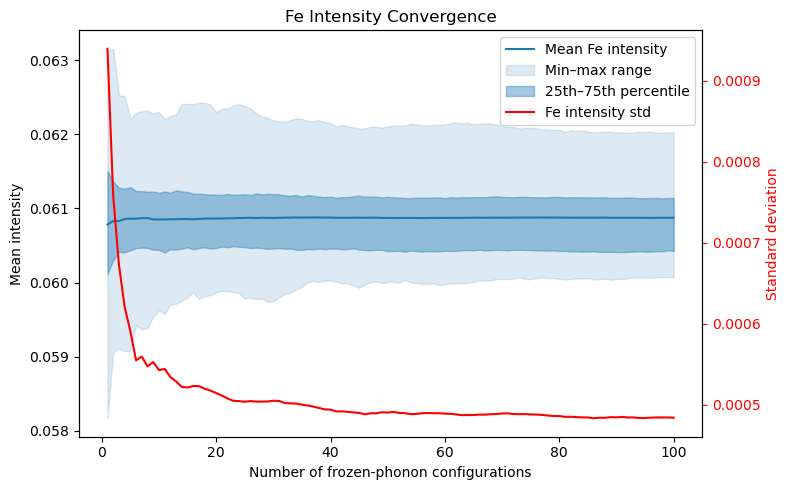

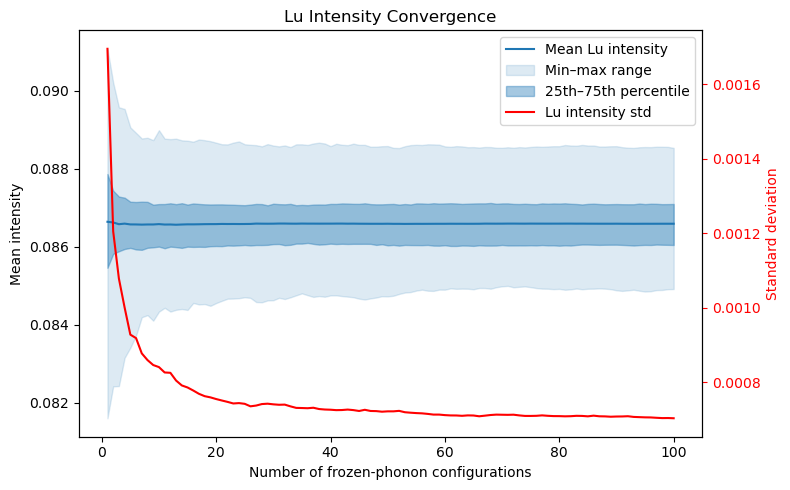

In [4]:
# Fe plot
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(ns, fe_means, label="Mean Fe intensity")
ax1.fill_between(ns, fe_mins, fe_maxs, color="C0", alpha=0.15, label="Min–max range")
ax1.fill_between(ns, fe_q25s, fe_q75s, color="C0", alpha=0.4, label="25th–75th percentile")
ax1.set_xlabel("Number of frozen-phonon configurations")
ax1.set_ylabel("Mean intensity")

ax2 = ax1.twinx()
ax2.plot(ns, fe_stds, color="red", label="Fe intensity std")
ax2.set_ylabel("Standard deviation", color="red")
ax2.tick_params(axis="y", colors="red")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right"
)

plt.title("Fe Intensity Convergence")
plt.tight_layout()
plt.show()

# Lu plot
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(ns, lu_means, label="Mean Lu intensity")
ax1.fill_between(ns, lu_mins, lu_maxs, color="C0", alpha=0.15, label="Min–max range")
ax1.fill_between(ns, lu_q25s, lu_q75s, color="C0", alpha=0.4, label="25th–75th percentile")
ax1.set_xlabel("Number of frozen-phonon configurations")
ax1.set_ylabel("Mean intensity")

ax2 = ax1.twinx()
ax2.plot(ns, lu_stds, color="red", label="Lu intensity std")
ax2.set_ylabel("Standard deviation", color="red")
ax2.tick_params(axis="y", colors="red")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.title("Lu Intensity Convergence")
plt.tight_layout()
plt.show()